# EDA: transactions

Utforskar rådatatabellen `transactions` i `data/kunder.db` (skapas av `databearbetning/01_ladda_data.py`).
Kör notebooken från repots rot så att relativa sökvägar fungerar.

In [1]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
conn = sqlite3.connect("data/kunder.db")

def q(sql):
    return pd.read_sql(sql, conn)

## 1. Översikt

In [2]:
q("""
SELECT COUNT(*)                    AS rader,
       COUNT(DISTINCT customer_id) AS unika_kunder,
       COUNT(DISTINCT invoice_no)  AS unika_ordrar,
       MIN(invoice_date)           AS forsta_datum,
       MAX(invoice_date)           AS sista_datum
FROM transactions
""").T

,0
rader,1067371
unika_kunder,5942
unika_ordrar,53628
forsta_datum,2009-12-01 07:45:00
sista_datum,2011-12-09 12:50:00


## 2. Rensningsfilter

- **Var för sig**: hur många rader filtret träffar i hela rådatan.
- **Kumulativt**: hur många *ytterligare* rader filtret tar bort när de föregående redan är applicerade.

Ordningen är samma som i `WHERE` i `databearbetning/queries.py`.

In [3]:
FILTER = [
    ("Saknat customer_id", "customer_id IS NULL"),
    ("quantity <= 0", "quantity <= 0"),
    ("unit_price <= 0", "unit_price <= 0"),
    ("invoice_no börjar med C", "invoice_no LIKE 'C%'"),
]

total = q("SELECT COUNT(*) AS n FROM transactions").n[0]
rader, tidigare = [], []
for namn, villkor in FILTER:
    var_for_sig = q(f"SELECT COUNT(*) AS n FROM transactions WHERE {villkor}").n[0]
    kvar_innan = " AND ".join(f"NOT ({v})" for v in tidigare) or "1"
    kumulativt = q(f"SELECT COUNT(*) AS n FROM transactions WHERE ({kvar_innan}) AND {villkor}").n[0]
    tidigare.append(villkor)
    rader.append((namn, var_for_sig, var_for_sig / total, kumulativt))

rensning = pd.DataFrame(rader, columns=["filter", "var_for_sig", "andel_av_total", "kumulativt_borttagna"])
rensning["kvar_efter"] = total - rensning.kumulativt_borttagna.cumsum()
rensning

,filter,var_for_sig,andel_av_total,kumulativt_borttagna,kvar_efter
0,Saknat customer_id,243007,0.227669,243007,824364
1,quantity <= 0,22950,0.021501,18744,805620
2,unit_price <= 0,6207,0.005815,71,805549
3,invoice_no börjar med C,19494,0.018264,0,805549


In [4]:
# Spara till rapporten
tabell = [
    f"Rådata: {total:,} rader.".replace(",", " "),
    "",
    "| Filter | Var för sig | Andel | Kumulativt borttagna | Kvar efter |",
    "| --- | ---: | ---: | ---: | ---: |",
]
for r in rensning.itertuples():
    tabell.append(
        f"| {r.filter} | {r.var_for_sig:,} | {r.andel_av_total:.1%} | {r.kumulativt_borttagna:,} | {r.kvar_efter:,} |".replace(",", " ")
    )
Path("rapport").mkdir(exist_ok=True)
Path("rapport/rensning.md").write_text("\n".join(tabell) + "\n")
print("\n".join(tabell))

Rådata: 1 067 371 rader.

| Filter | Var för sig | Andel | Kumulativt borttagna | Kvar efter |
| --- | ---: | ---: | ---: | ---: |
| Saknat customer_id | 243 007 | 22.8% | 243 007 | 824 364 |
| quantity <= 0 | 22 950 | 2.2% | 18 744 | 805 620 |
| unit_price <= 0 | 6 207 | 0.6% | 71 | 805 549 |
| invoice_no börjar med C | 19 494 | 1.8% | 0 | 805 549 |


C-fakturorna är redan borta när C-filtret appliceras: 19 493 av 19 494 har negativ quantity, och den sista (C496350, en manuell justering) saknar customer_id. Filtret tar alltså bort 0 rader kumulativt men ligger kvar som skydd. Saknat customer_id är det enda filtret som spelar roll på riktigt: det tar bort 22,8 % av raderna, och de raderna går inte att använda eftersom segmenteringen görs per kund.

Resten av notebooken använder rensad data, eftersom det är den modellen tränas på.

In [5]:
rensad = q("""
SELECT invoice_no, stock_code, description, quantity, unit_price, customer_id, country
FROM transactions
WHERE customer_id IS NOT NULL
  AND quantity > 0
  AND unit_price > 0
  AND invoice_no NOT LIKE 'C%'
""")
rensad["belopp"] = rensad.quantity * rensad.unit_price

kunder = rensad.groupby("customer_id").agg(
    ordrar=("invoice_no", "nunique"),
    monetary=("belopp", "sum"),
)
print(f"Rader: {len(rensad):,}  Kunder: {len(kunder):,}  Ordrar: {rensad.invoice_no.nunique():,}")

Rader: 805,549  Kunder: 5,878  Ordrar: 36,969


## 3. Antal ordrar per kund

count    5878.0
mean        6.3
std        13.0
min         1.0
25%         1.0
50%         3.0
75%         7.0
max       398.0
Name: ordrar, dtype: float64
Kunder med exakt en order: 1,623 (27.6%)


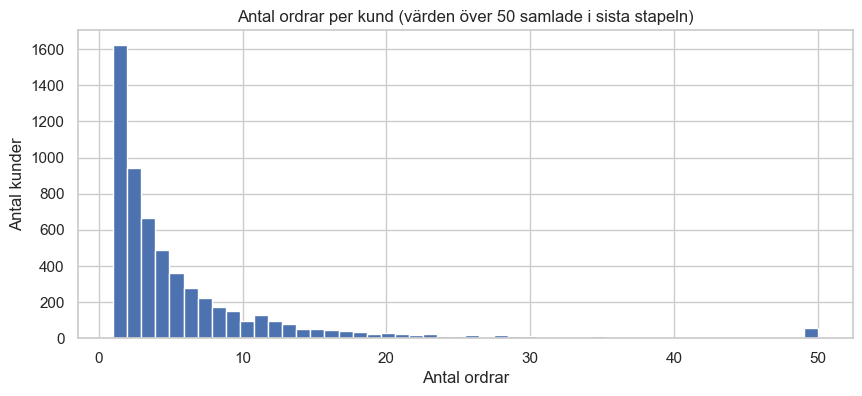

In [6]:
print(kunder.ordrar.describe().round(1))
print(f"Kunder med exakt en order: {(kunder.ordrar == 1).sum():,} ({(kunder.ordrar == 1).mean():.1%})")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(kunder.ordrar.clip(upper=50), bins=50)
ax.set(title="Antal ordrar per kund (värden över 50 samlade i sista stapeln)",
       xlabel="Antal ordrar", ylabel="Antal kunder")
plt.show()

**För modellen:** 27,6 % av kunderna har bara en order, så `avg_days_between_orders` blir NULL för dem och måste hanteras explicit, och den långa svansen upp till 398 ordrar gör att frequency behöver logtransformeras.

## 4. Totalt spenderat belopp per kund

count      5878.0
mean       3019.0
std       14738.0
min           3.0
25%         349.0
50%         899.0
75%        2307.0
max      608822.0
Name: monetary, dtype: float64
Skevhet: 25.3  Skevhet efter log1p: 0.3


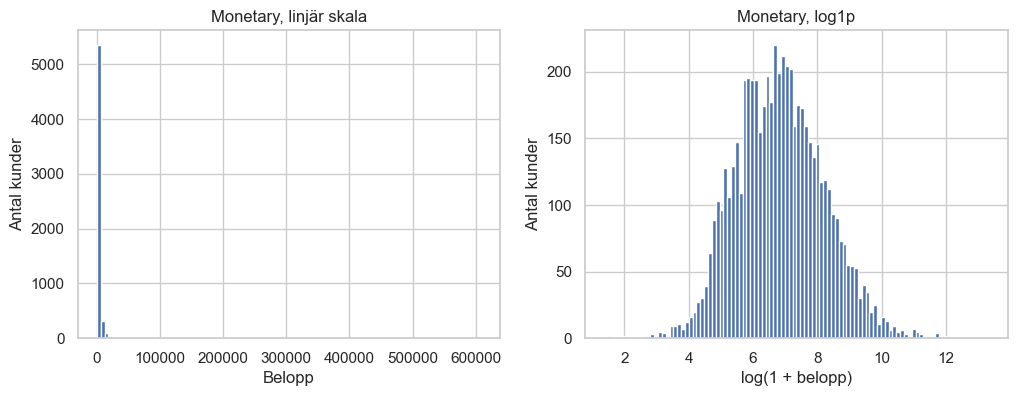

In [7]:
print(kunder.monetary.describe().round(0))
print(f"Skevhet: {kunder.monetary.skew():.1f}  Skevhet efter log1p: {np.log1p(kunder.monetary).skew():.1f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(kunder.monetary, bins=100)
ax1.set(title="Monetary, linjär skala", xlabel="Belopp", ylabel="Antal kunder")
ax2.hist(np.log1p(kunder.monetary), bins=100)
ax2.set(title="Monetary, log1p", xlabel="log(1 + belopp)", ylabel="Antal kunder")
plt.show()

**För modellen:** med skevhet 25,3 skulle ett fåtal grossister dra iväg en centroid på egen hand, men efter log1p är fördelningen nästan symmetrisk (skevhet 0,3), så monetary måste logtransformeras före skalningen.

## 5. Topp 10 länder efter antal rader

country
United Kingdom    90.0%
Germany            2.1%
EIRE               2.0%
France             1.7%
Netherlands        0.6%
Spain              0.5%
Belgium            0.4%
Switzerland        0.4%
Portugal           0.3%
Australia          0.2%
Name: count, dtype: str


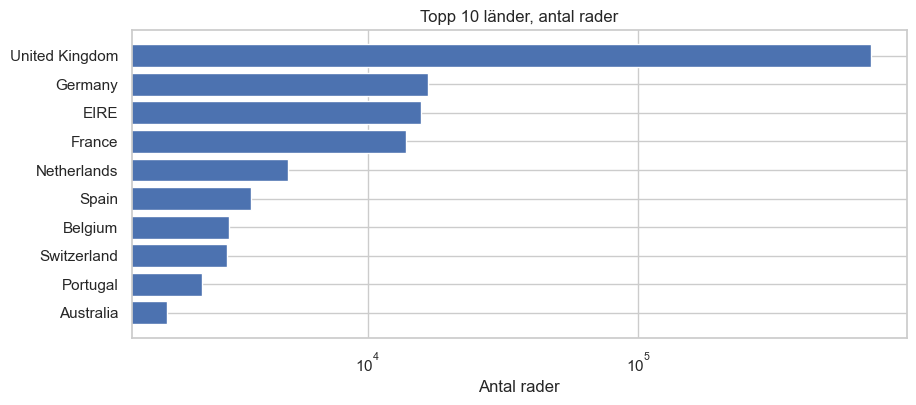

In [8]:
lander = rensad.country.value_counts()
topp = lander.head(10)
print((topp / len(rensad)).map("{:.1%}".format))

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(topp.index[::-1], topp.values[::-1])
ax.set(title="Topp 10 länder, antal rader", xlabel="Antal rader")
ax.set_xscale("log")
plt.show()

**För modellen:** 90 % av raderna kommer från Storbritannien, så land ger nästan ingen information att skilja kunder åt och tas inte med som feature.

## 6. De 20 vanligaste stock_code

En stock_code kan ha flera stavningar av beskrivningen, så den vanligaste visas.

In [9]:
vanligaste_beskrivning = (
    rensad.groupby(["stock_code", "description"]).size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
    .drop_duplicates("stock_code")
    .set_index("stock_code").description
)
topp_varor = rensad.stock_code.value_counts().head(20).rename("rader").to_frame()
topp_varor["description"] = vanligaste_beskrivning
topp_varor

,rader,description
stock_code,,
85123A,5188,WHITE HANGING HEART T-LIGHT HOLDER
22423,3428,REGENCY CAKESTAND 3 TIER
85099B,3360,JUMBO BAG RED RETROSPOT
84879,2777,ASSORTED COLOUR BIRD ORNAMENT
20725,2678,LUNCH BAG RED RETROSPOT
21212,2654,PACK OF 72 RETROSPOT CAKE CASES
21034,2141,REX CASH+CARRY JUMBO SHOPPER
47566,2121,PARTY BUNTING
20727,2117,LUNCH BAG BLACK SKULL.


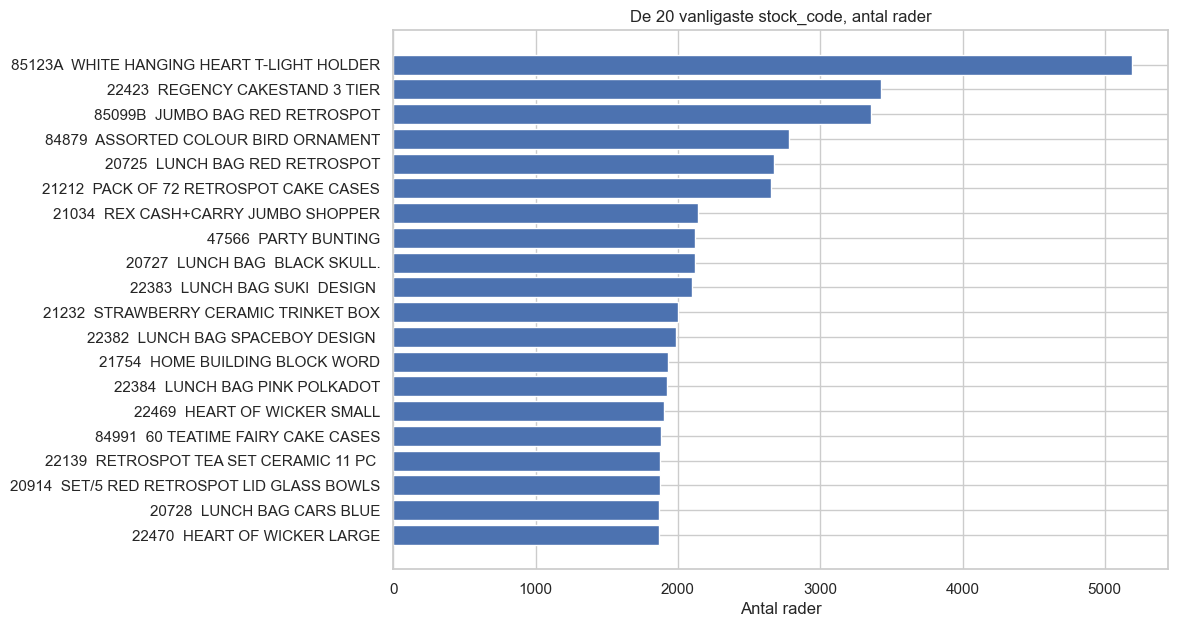

In [10]:
fig, ax = plt.subplots(figsize=(10, 7))
etiketter = [f"{kod}  {besk}" for kod, besk in zip(topp_varor.index, topp_varor.description)]
ax.barh(etiketter[::-1], topp_varor.rader.values[::-1])
ax.set(title="De 20 vanligaste stock_code, antal rader", xlabel="Antal rader")
plt.show()

**För modellen:** inga enskilda varor dominerar (den vanligaste står för under 1 % av raderna) och sortimentet är brett, så antal unika produkter per kund säger mer om kunden än vilka specifika stock_codes den köper.